In [ ]:
import numpy as np
from numpy import ndarray
import pandas as pd
import tensorflow as tf
from matplotlib.pyplot import subplots, show, xticks  
from PIL import Image
from keras.datasets.cifar10 import load_data as load_cifar10
# model building imports
from keras import Model, Sequential, Input
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model, Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.layers import LeakyReLU
from keras.ops import add
from keras.utils import to_categorical
# model training imports
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler

In [2]:
import os

os.chdir("/Users/carlo/OneDrive/Documentos/Mestrado/2S/DL/project/deep_learning_project")
print("Working directory:", os.getcwd())

Working directory: c:\Users\carlo\OneDrive\Documentos\Mestrado\2S\DL\project\deep_learning_project


In [3]:
dataset_path = "data"

for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)

    if os.path.isdir(artist_path):
        for img in os.listdir(artist_path):
            print(os.path.join(artist_path, img))

data\wikiart\Albrecht_Durer
data\wikiart\Boris_Kustodiev
data\wikiart\Camille_Pissarro
data\wikiart\Childe_Hassam
data\wikiart\Claude_Monet
data\wikiart\Edgar_Degas
data\wikiart\Eugene_Boudin
data\wikiart\Gustave_Dore
data\wikiart\Ilya_Repin
data\wikiart\Ivan_Aivazovsky
data\wikiart\Ivan_Shishkin
data\wikiart\John_Singer_Sargent
data\wikiart\Marc_Chagall
data\wikiart\Martiros_Saryan
data\wikiart\Nicholas_Roerich
data\wikiart\Pablo_Picasso
data\wikiart\Paul_Cezanne
data\wikiart\Pierre_Auguste_Renoir
data\wikiart\Pyotr_Konchalovsky
data\wikiart\Raphael_Kirchner
data\wikiart\Rembrandt
data\wikiart\Salvador_Dali
data\wikiart\Vincent_van_Gogh
data\__MACOSX\._wikiart
data\__MACOSX\wikiart


In [11]:
import os

dataset_path = "data/wikiart"

for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)
    if os.path.isdir(artist_path):
        for image_file in os.listdir(artist_path):
            image_path = os.path.join(artist_path, image_file)
            print(image_path)

data/wikiart\Albrecht_Durer\albrecht-durer_a-life-of-the-virgin-1503.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_a-nuremberg-costume-study-1500.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_a-sea-monster-bearing-away-a-princess-1528.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_a-young-hare.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_abduction-of-a-woman-rape-of-the-sabine-women-1495.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_abduction-of-proserpine-on-a-unicorn-1516.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_abduction.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-1507.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-and-eve-1504-1.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-and-eve-1504.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-and-eve-1507.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-and-eve-1510.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adam-and-eve.jpg
data/wikiart\Albrecht_Durer\albrecht-durer_adoration-fragment-1.jpg
data/wik

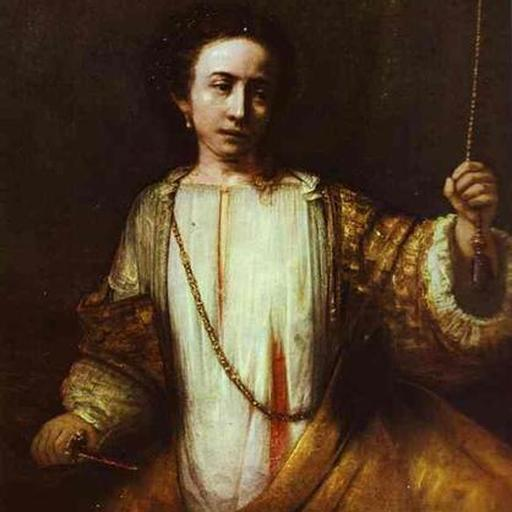

In [ ]:
img = Image.open("data/wikiart/Rembrandt/rembrandt_lucretia.jpg")
img

In [6]:
import os

#dataset_path = "../data/wikiart"
artist_dic={}
for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)
    
    if os.path.isdir(artist_path):
        
        images = [f for f in os.listdir(artist_path)
                  if f.lower().endswith((".jpg",".jpeg",".png",".bmp",".gif"))]
        artist_dic[artist]= len(images)
        print(artist, len(images))

Albrecht_Durer 580
Boris_Kustodiev 444
Camille_Pissarro 621
Childe_Hassam 385
Claude_Monet 934
Edgar_Degas 428
Eugene_Boudin 389
Gustave_Dore 528
Ilya_Repin 378
Ivan_Aivazovsky 404
Ivan_Shishkin 364
John_Singer_Sargent 549
Marc_Chagall 536
Martiros_Saryan 403
Nicholas_Roerich 1274
Pablo_Picasso 534
Paul_Cezanne 406
Pierre_Auguste_Renoir 975
Pyotr_Konchalovsky 644
Raphael_Kirchner 362
Rembrandt 544
Salvador_Dali 336
Vincent_van_Gogh 1322


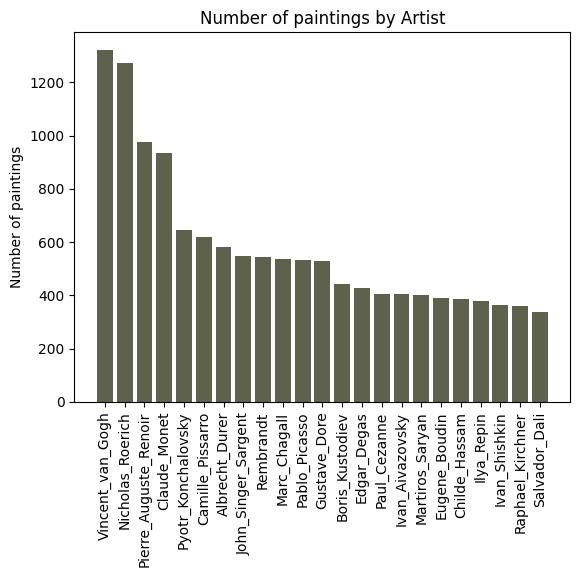

In [7]:
fig, ax = subplots()
artist_dic = dict(sorted(artist_dic.items(), key=lambda x: x[1], reverse=True))
artist = list(artist_dic.keys())
painting = list(artist_dic.values())


ax.bar(artist, painting, color= '#5e614b')

ax.set_ylabel('Number of paintings')
ax.set_title('Number of paintings by Artist')

xticks(rotation=90)
show()

In [ ]:
len(artist_dic)

23

There are 23 artists in our datasets, where the ones with the most paitings are **Vicent Van Gogh** and **Nicholar Roerich** with 1322 and 1274, respectively.

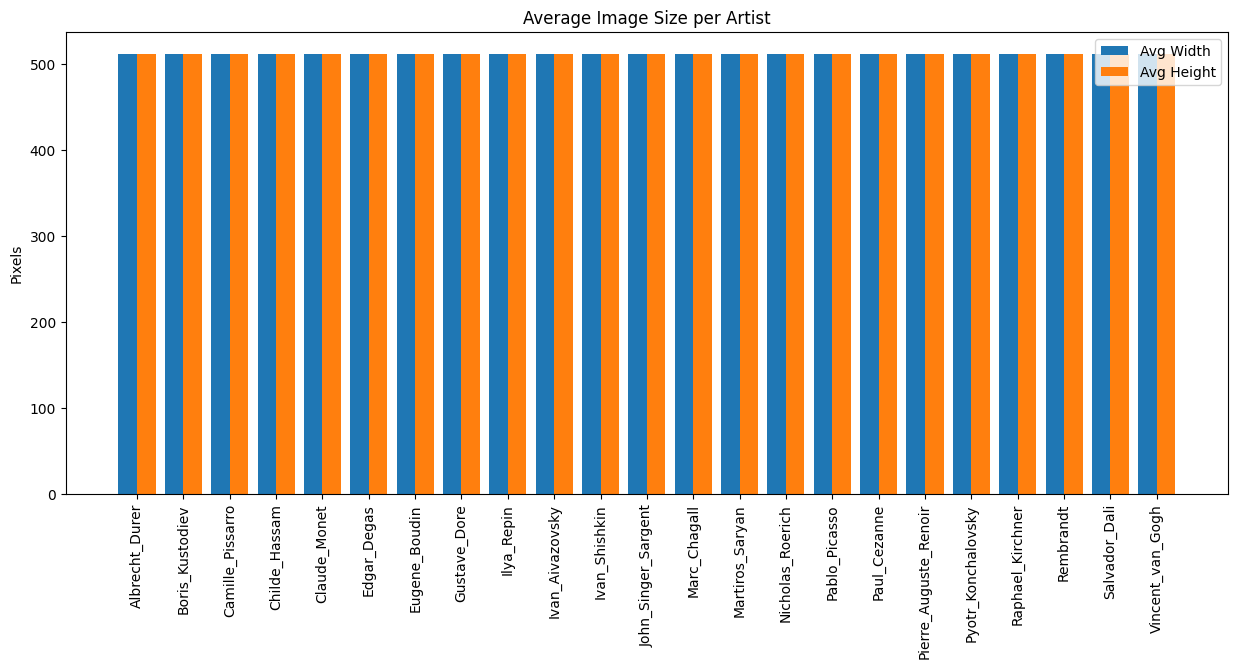

In [12]:


# collect sizes per artist
artist_sizes = {}

for artist in os.listdir(dataset_path):
    artist_path = os.path.join(dataset_path, artist)
    
    if os.path.isdir(artist_path):
        widths = []
        heights = []
        for img_file in os.listdir(artist_path):
            img_path = os.path.join(artist_path, img_file)
            try:
                with Image.open(img_path) as img:
                    w, h = img.size
                    widths.append(w)
                    heights.append(h)
            except:
                pass  # skip corrupted images
        
        if widths:
            artist_sizes[artist] = {
                "avg_width": np.mean(widths),
                "avg_height": np.mean(heights)
            }

# plot
artists = list(artist_sizes.keys())
avg_widths = [artist_sizes[a]["avg_width"] for a in artists]
avg_heights = [artist_sizes[a]["avg_height"] for a in artists]

x = np.arange(len(artists))
fig, ax = subplots(figsize=(15, 6))

ax.bar(x - 0.2, avg_widths, 0.4, label='Avg Width')
ax.bar(x + 0.2, avg_heights, 0.4, label='Avg Height')

ax.set_xticks(x)
ax.set_xticklabels(artists, rotation=90)
ax.set_ylabel('Pixels')
ax.set_title('Average Image Size per Artist')
ax.legend()

#tight_layout()
show()

In [18]:
val_ds


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
# ── 1. Load ──────────────────────────────────────────────────────────────────
dataset_path = "data/wikiart"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2, 
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# ── 2. Extract class info (before any transforms) ────────────────────────────
class_names = train_ds.class_names
num_classes  = len(class_names)

# ── 3. Define transforms ──────────────────────────────────────────────────────
normalization_layer = tf.keras.layers.Rescaling(1./255)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomContrast(0.2),
], name="augmentation")

# ── 4. Apply transforms ───────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (train_ds
    .map(lambda x, y: (normalization_layer(x), y),        # normalize once
         num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (augmentation(x, training=True), y), # augment only train
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

val_ds = (val_ds
    .map(lambda x, y: (normalization_layer(x), y),        # normalize once
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))                                   # no augmentation

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Found 13340 files belonging to 23 classes.
Using 2668 files for validation.


In [ ]:
'''data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])'''

'data_augmentation = tf.keras.Sequential([\n    tf.keras.layers.RandomFlip("horizontal"),\n    tf.keras.layers.RandomRotation(0.1),\n    tf.keras.layers.RandomZoom(0.1),\n])'

In [ ]:
'''model = tf.keras.Sequential([
    #data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])'''

'model = tf.keras.Sequential([\n    #data_augmentation,\n    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(128,128,3)),\n    tf.keras.layers.MaxPooling2D(),\n    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),\n    tf.keras.layers.MaxPooling2D(),\n    tf.keras.layers.Flatten(),\n    tf.keras.layers.Dense(128, activation="relu"),\n    tf.keras.layers.Dense(num_classes, activation="softmax")\n])'

In [ ]:
'''model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)'''

'model.compile(\n    optimizer="adam",\n    loss="sparse_categorical_crossentropy",\n    metrics=["accuracy"]\n)'

In [ ]:
#model.fit(train_ds, validation_data=val_ds, epochs=20)

# BLBLA


In [ ]:
# from keras import layers
# from keras import ops

# print(f"x_train shape: {train_ds.shape} - y_train shape: {y_train.shape}")
# print(f"x_test shape: {x_test.shape} - y_test shape: {y_test.shape}")

In [15]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>